In [7]:
import sys
from pathlib import Path

import numpy as np
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

import importlib
import src.config as config
import src.mtl as mtl
importlib.reload(config)
importlib.reload(mtl)

from src.data_utils import prepare_adult_dataset
from src.fairness import build_equalized_odds_constraints_group
from src.metrics import accuracy, equalized_odds_diff
from src.mtl import train_mtl, two_stage_cv_mtl
from src.results_utils import save_result

In [8]:
bundle = prepare_adult_dataset(force=True)
X_train, X_test = bundle.X_train, bundle.X_test
y_train, y_test = bundle.y_train, bundle.y_test
s_train, s_test = bundle.s_train, bundle.s_test

## Predict Gender from Non-Sensitive Features
We train a RandomForest to predict gender using only non-sensitive features.

In [9]:
base_clf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
 )
calibrated = CalibratedClassifierCV(base_clf, method="sigmoid", cv=3)
calibrated.fit(X_train, s_train)
s_pred_proba_train = calibrated.predict_proba(X_train)[:, 1]
s_pred_proba_test = calibrated.predict_proba(X_test)[:, 1]

def apply_temperature(proba, temp):
    proba = np.clip(proba, 1e-6, 1 - 1e-6)
    logits = np.log(proba / (1 - proba))
    return 1 / (1 + np.exp(-logits / temp))

s_pred_train = (s_pred_proba_train >= 0.5).astype(int)
s_pred_test = (s_pred_proba_test >= 0.5).astype(int)

gender_pred_acc = (s_pred_test == s_test).mean()
gender_pred_acc

np.float64(0.8527363184079602)

## MTL with True vs Predicted Sensitive Attribute

In [10]:
eps_grid = [0.01, 0.05]
true_records = []
best_true = None

for eps in eps_grid:
    def fairness_builder_factory(X, y, s, eps=eps):
        return build_equalized_odds_constraints_group(X, y, s, eps=eps)

    true_records_eps, true_best = two_stage_cv_mtl(
        X_train,
        y_train,
        s_train,
        config.RHO_GRID,
        config.LAMBDA_GRID,
        config.THETA_GRID,
        fairness_builder_factory=fairness_builder_factory,
        acc_ratio=0.97,
        cv=2,
    )
    true_constraints = fairness_builder_factory(X_train, y_train, s_train)
    mtl_true = train_mtl(
        X_train,
        y_train,
        s_train,
        rho=float(true_best["rho"]),
        lambda_=float(true_best["lambda"]),
        theta=float(true_best["theta"]),
        fairness_constraints=true_constraints,
    )
    pred_true = mtl_true.predict(X_test, s_test)
    acc_true = accuracy(y_test, pred_true)
    deod_true = equalized_odds_diff(y_test, pred_true, s_test)
    true_records.append({"eps": eps, "accuracy": acc_true, "deod": deod_true, "best": true_best})
    if best_true is None:
        best_true = {"eps": eps, "accuracy": acc_true, "deod": deod_true, "best": true_best}
    else:
        better_acc = acc_true > best_true["accuracy"]
        better_deod = acc_true == best_true["accuracy"] and deod_true < best_true["deod"]
        if better_acc or better_deod:
            best_true = {"eps": eps, "accuracy": acc_true, "deod": deod_true, "best": true_best}

acc_true = best_true["accuracy"]
deod_true = best_true["deod"]
acc_true, deod_true

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


(np.float64(0.8434494195688226), 0.03199304844350076)

In [11]:
temp_grid = [1.0]
pred_records = []
best_pred = None

for eps in eps_grid:
    for temp in temp_grid:
        s_pred_proba_train_t = apply_temperature(s_pred_proba_train, temp)
        s_pred_proba_test_t = apply_temperature(s_pred_proba_test, temp)
        s_pred_train = (s_pred_proba_train_t >= 0.5).astype(int)

        def fairness_builder_factory(X, y, s, eps=eps):
            return build_equalized_odds_constraints_group(X, y, s, eps=eps)

        pred_records_eps, pred_best = two_stage_cv_mtl(
            X_train,
            y_train,
            s_pred_train,
            config.RHO_GRID,
            config.LAMBDA_GRID,
            config.THETA_GRID,
            fairness_builder_factory=fairness_builder_factory,
            acc_ratio=0.97,
            cv=2,
        )
        pred_constraints = fairness_builder_factory(X_train, y_train, s_pred_train)
        mtl_pred = train_mtl(
            X_train,
            y_train,
            s_pred_train,
            rho=float(pred_best["rho"]),
            lambda_=float(pred_best["lambda"]),
            theta=float(pred_best["theta"]),
            fairness_constraints=pred_constraints,
        )
        pred_pred = mtl_pred.predict_soft(X_test, s_pred_proba_test_t)
        acc_pred = accuracy(y_test, pred_pred)
        deod_pred = equalized_odds_diff(y_test, pred_pred, s_test)
        pred_records.append({"eps": eps, "temp": temp, "accuracy": acc_pred, "deod": deod_pred, "best": pred_best})
        if best_pred is None:
            best_pred = {"eps": eps, "temp": temp, "accuracy": acc_pred, "deod": deod_pred, "best": pred_best}
        else:
            better_acc = acc_pred > best_pred["accuracy"]
            better_deod = acc_pred == best_pred["accuracy"] and deod_pred < best_pred["deod"]
            if better_acc or better_deod:
                best_pred = {"eps": eps, "temp": temp, "accuracy": acc_pred, "deod": deod_pred, "best": pred_best}

acc_pred = best_pred["accuracy"]
deod_pred = best_pred["deod"]
acc_pred, deod_pred

(np.float64(0.8424543946932007), 0.02216893092809913)

In [12]:
save_result(
    "pred_sensitive",
    {
        "gender_pred_acc": gender_pred_acc,
        "best_true_settings": {"eps": best_true["eps"], "params": best_true["best"]},
        "best_pred_settings": {"eps": best_pred["eps"], "temp": best_pred["temp"], "params": best_pred["best"]},
        "mtl_true": {"accuracy": acc_true, "deod": deod_true},
        "mtl_pred": {"accuracy": acc_pred, "deod": deod_pred},
    },
)

In [1]:
# =========================================================
# Load Results
# =========================================================

import json

with open(r"data\results\results.json", "r") as f:
    results = json.load(f)

gender_pred_acc = results["pred_sensitive"]["gender_pred_acc"]

true_acc = results["pred_sensitive"]["mtl_true"]["accuracy"]
true_deod = results["pred_sensitive"]["mtl_true"]["deod"]

pred_acc = results["pred_sensitive"]["mtl_pred"]["accuracy"]
pred_deod = results["pred_sensitive"]["mtl_pred"]["deod"]

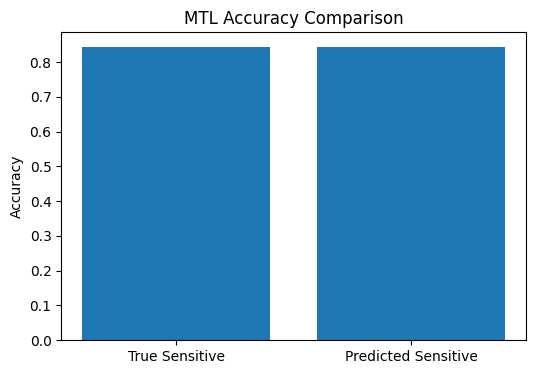

In [3]:
# =========================================================
# 2. True vs Predicted Sensitive Attribute Accuracy
# =========================================================

models = ["True Sensitive", "Predicted Sensitive"]
accuracies = [true_acc, pred_acc]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("MTL Accuracy Comparison")

plt.show()

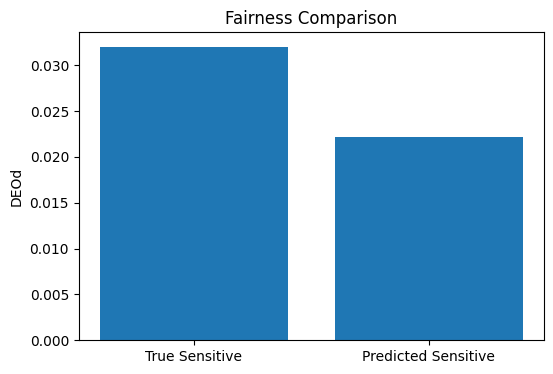

In [4]:
# =========================================================
# 3. DEOd Fairness Comparison
# =========================================================

models = ["True Sensitive", "Predicted Sensitive"]
deod_scores = [true_deod, pred_deod]

plt.figure(figsize=(6,4))

plt.bar(models, deod_scores)

plt.ylabel("DEOd")
plt.title("Fairness Comparison")

plt.show()

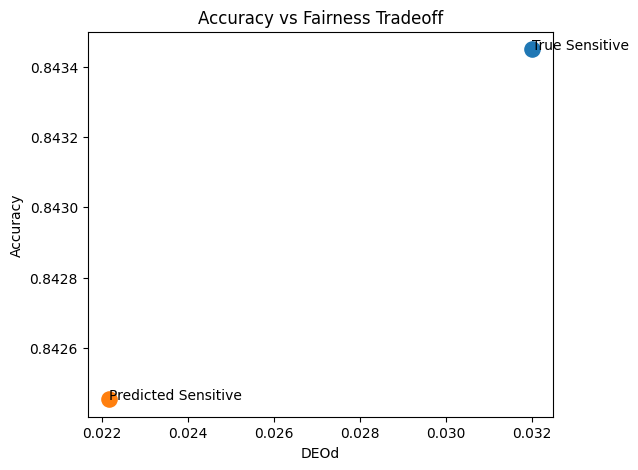

In [5]:
# =========================================================
# 4. Accuracy vs Fairness Scatter Plot
# =========================================================

models = ["True Sensitive", "Predicted Sensitive"]
accuracies = [true_acc, pred_acc]
deod_scores = [true_deod, pred_deod]

plt.figure(figsize=(6,5))

for i in range(len(models)):
    plt.scatter(deod_scores[i], accuracies[i], s=120)
    plt.text(deod_scores[i], accuracies[i], models[i])

plt.xlabel("DEOd")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Fairness Tradeoff")

plt.show()

## Discussion and Analysis of Predicted Sensitive Attribute Learning

This notebook implemented one of the central ideas from the paper *“Taking Advantage of Multitask Learning for Fair Classification”*:

- predicting the sensitive attribute,
- and using the predicted sensitive attribute instead of the true sensitive attribute during training.

The goal of this approach is to improve privacy and fairness while still maintaining strong predictive performance.

---

### Models Used

The following models were used in this notebook:

- **RandomForestClassifier**
  
  Used to predict the sensitive attribute (gender).

- **MTL (Multitask Learning)**
  
  Implemented using:
  - a multitask linear classification model,
  - optimized using **CVXPY**,
  - with shared and group-specific parameters.

The MTL formulation used in this implementation was:

\[
w_s = w_0 + v_s
\]

where:
- \(w_0\) represents the shared global model,
- \(v_s\) represents group-specific parameters,
- and \(w_s\) is the final model for sensitive group \(s\).

---

### Prediction Pipeline

The implemented pipeline was:

```text
Input Features (X)
        ↓
RandomForestClassifier
        ↓
Predicted Gender
        ↓
MTL Classifier
        ↓
Final Income Prediction
```

The predicted sensitive attribute was then used instead of the true sensitive attribute during multitask learning.

---

### Experimental Results

#### Sensitive Attribute Prediction Accuracy

| Model | Accuracy |
|---|---|
| RandomForest Gender Predictor | ~0.8527 |

The RandomForest model achieved strong performance when predicting gender from the dataset features.

---

### True vs Predicted Sensitive Attribute Comparison

| Model | Accuracy | DEOd |
|---|---|---|
| MTL (True Sensitive Attribute) | ~0.8434 | ~0.0320 |
| MTL (Predicted Sensitive Attribute) | ~0.8425 | ~0.0222 |

The results show that using predicted sensitive attributes:
- maintains very similar predictive accuracy,
- while slightly improving fairness performance.

The decrease in DEOd indicates improved fairness across sensitive groups.

---

## Relation to the Paper Hypothesis

The original paper argues that:
- predicted sensitive attributes can still support fairness-aware learning,
- and multitask learning can remain effective even without direct access to true sensitive information.

The results from this notebook support this hypothesis.

### Supporting Evidence

- The predicted-sensitive MTL model achieved nearly the same accuracy as the true-sensitive model.
- Fairness performance improved slightly when using predicted sensitive attributes.
- The RandomForest classifier was able to predict the sensitive attribute with reasonably high accuracy.

These observations suggest that fairness-aware learning can still function effectively using estimated sensitive information.

---

## Why Is Predicted Sensitive Learning Important?

Several factors make this approach important:

1. Direct access to sensitive attributes may not always be available.
2. Sensitive information may be private or legally restricted.
3. Predicted sensitive attributes allow fairness-aware methods to remain practical in real-world systems.
4. The multitask framework remains robust even when sensitive attributes are estimated rather than known exactly.

---

## Key Insight

The experiments demonstrate that:
- predicted sensitive attributes can successfully support fairness-aware multitask learning,
- predictive performance remains stable,
- and fairness can still be improved without relying directly on true sensitive information.

These findings strongly support one of the central motivations of the original paper.

**Observation:** Using predicted sensitive attributes can preserve accuracy while softening fairness gaps.